In [1]:
import os
import json
import time
import joblib
import random 
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from openai import OpenAI

### Config

In [2]:
DATA_FILE = "../data/processed/cleaned_emotions_shared.csv"
SPLIT_FILE = "../data/splits/shared_split.json"

ML_METADATA_FILE = "../models/ml_all_models_metadata.json"
DL_MODEL_FILE = "../models/bilstm_model.keras"
DL_META_FILE = "../models/dl_metadata.json"
TOKENIZER_FILE = "../models/tokenizer.json"

OUTPUT_PRED_FILE = "../data/processed/hybrid_all_predictions.csv"
OUTPUT_SUMMARY_FILE = "../data/processed/hybrid_all_summary.csv"
OUTPUT_PER_CLASS_FILE = "../data/processed/hybrid_all_per_class.csv"

CONF_THRESHOLD = 0.70
USE_Llama = True
RANDOM_STATE = 42

# few-shot config
FEW_SHOT_PER_LABEL = 2
MAX_TEXT_LEN_IN_PROMPT = 180

total_start_time = time.time()
random.seed(RANDOM_STATE)

### Llama via Ollama

In [3]:
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

Llama_MODEL = "llama3.1:8b"
print("AI ready:", Llama_MODEL)

AI ready: llama3.1:8b


### Helper functions

In [4]:
def shorten_text(text, max_len=180):
    text = str(text).strip().replace("\n", " ")
    if len(text) <= max_len:
        return text
    return text[:max_len].strip() + "..."

def get_summary_metrics(y_true, y_pred, model_name, elapsed_time=None):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_Macro": f1_score(y_true, y_pred, average="macro"),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted")
    }
    if elapsed_time is not None:
        row["Run_Time_Seconds"] = round(elapsed_time, 4)
    return row

def get_per_class_report(y_true, y_pred, model_name, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for label in labels:
        rows.append({
            "Model": model_name,
            "Emotion": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1_Score": report[label]["f1-score"],
            "Support": int(report[label]["support"])
        })
    return pd.DataFrame(rows)

def print_model_result(y_true, y_pred, model_name, labels):
    print(f"\n===== {model_name} =====")
    print("Accuracy    :", accuracy_score(y_true, y_pred))
    print("F1 Macro    :", f1_score(y_true, y_pred, average="macro"))
    print("F1 Weighted :", f1_score(y_true, y_pred, average="weighted"))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=labels))

### Build few-shot bank from real training data

In [5]:
def build_few_shot_bank(train_df, labels, shots_per_label=2, random_state=42):
    """
    สร้าง few-shot bank จาก train set จริง
    - ครอบคลุมทุก emotion
    - ใช้ train set เท่านั้น เพื่อไม่ให้ data leakage จาก test
    """
    rng = random.Random(random_state)
    bank = []

    for label in labels:
        label_df = train_df[train_df["label"] == label].copy()

        if label_df.empty:
            continue

        # เพิ่มคอลัมน์ความยาว เพื่อคัดตัวอย่างที่ไม่สั้น/ไม่ยาวเกินไป
        label_df["text_len"] = label_df["text"].astype(str).str.len()

        # กันตัวอย่างสั้นเกินไป
        candidate_df = label_df[label_df["text_len"] >= 15].copy()
        if candidate_df.empty:
            candidate_df = label_df.copy()

        # สุ่มแบบ reproducible
        idx_list = candidate_df.index.tolist()
        rng.shuffle(idx_list)

        selected_idx = idx_list[:shots_per_label]
        selected_df = candidate_df.loc[selected_idx]

        for _, row in selected_df.iterrows():
            bank.append({
                "text": shorten_text(row["text"], MAX_TEXT_LEN_IN_PROMPT),
                "label": row["label"]
            })

    return bank

def format_few_shot_bank(few_shot_bank):
    """
    แปลง few-shot bank เป็นข้อความสำหรับใส่ใน prompt
    """
    blocks = []
    for ex in few_shot_bank:
        block = (
            f'Text: "{ex["text"]}"\n'
            f'Label: "{ex["label"]}"'
        )
        blocks.append(block)
    return "\n\n".join(blocks)

### LLAMA FUNCTION

In [6]:
def llama_refine(text, pred_label, allowed_labels, few_shot_prompt):
    try:
        labels_str = ", ".join(allowed_labels)

        prompt = f"""You are an emotion classification assistant.

Allowed labels: {labels_str}

Here are labeled examples from the real training data:

{few_shot_prompt}

Now classify this case.

Text:
"{text}"

Predicted label:
"{pred_label}"

Task:
Check whether the predicted label matches the meaning of the text.

Rules:
1. If the predicted label is correct, return it unchanged.
2. If the predicted label is incorrect, return a better label from the allowed labels.
3. Use only one label from the allowed labels.
4. Reply with ONLY one label and nothing else.
"""

        response = client.chat.completions.create(
            model=Llama_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        output = response.choices[0].message.content.strip().lower()

        for label in allowed_labels:
            if label.lower() == output:
                return label

        for label in allowed_labels:
            if label.lower() in output:
                return label

        return pred_label

    except Exception as e:
        print("Llama error:", e)
        return pred_label


### Load data

In [7]:
df = pd.read_csv(DATA_FILE)

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    split = json.load(f)

train_df = df[df["row_id"].isin(split["train_ids"])].copy()
test_df = df[df["row_id"].isin(split["test_ids"])].copy()

texts = test_df["text"].tolist()
y_true = test_df["label"].tolist()

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index())

summary_rows = []
per_class_frames = []

result_df = test_df[["row_id", "text", "label"]].copy()


Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64

Train label counts:
label
angry      228
disgust    299
fear       276
happy      164
neutral    350
sad        195
Name: count, dtype: int64

Test label counts:
label
angry      49
disgust    64
fear       60
happy      35
neutral    75
sad        41
Name: count, dtype: int64


### LOAD ML METADATA

In [8]:
with open(ML_METADATA_FILE, "r", encoding="utf-8") as f:
    ml_meta = json.load(f)

labels = ml_meta["labels"]

### Build few-shot bank once

In [9]:
few_shot_bank = build_few_shot_bank(
    train_df=train_df,
    labels=labels,
    shots_per_label=FEW_SHOT_PER_LABEL,
    random_state=RANDOM_STATE
)

few_shot_prompt = format_few_shot_bank(few_shot_bank)

print("\n===== FEW-SHOT BANK =====")
print(f"Total few-shot examples: {len(few_shot_bank)}")
for i, ex in enumerate(few_shot_bank, start=1):
    print(f'{i}. [{ex["label"]}] {ex["text"]}')


===== FEW-SHOT BANK =====
Total few-shot examples: 12
1. [angry] ive been waiting for an hour this is ridiculous
2. [angry] i am not paying for a mistake you made
3. [disgust] the taste in my mouth during stitching after surgery is awful because blood medicine and saliva are mixing together and it is making me feel sick that part is really bothering me
4. [disgust] ive been breathing foodcontaminated bone smell for two days i feel sick about it
5. [fear] i am trying not to panic about stitching after surgery but the throbbing has been so strong while the area is still sore that i keep expecting a sharp jolt that is why i am struggl...
6. [fear] even hearing that we need pressing on the painful side makes me panic a little because the swelling has been painful while the area is still sore and i do not trust this area at al...
7. [happy] that makes me feel happy and relieved
8. [happy] i can already feel some relief after deep cleaning around the sore tooth especially because that deep 

### LOAD ML

In [10]:
vectorizer = joblib.load(ml_meta["vectorizer_file"])
X_test_ml = vectorizer.transform(texts)


###  ML LOOP

In [11]:
for model_name, info in ml_meta.items():
    if model_name in ["labels", "vectorizer_file"]:
        continue

    print("\n===== ML:", model_name, "=====")

    model = joblib.load(info["model_path"])

    base_start = time.time()
    preds = model.predict(X_test_ml)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_ml)
        confs = probs.max(axis=1)
    else:
        confs = np.ones(len(preds)) * 0.5
    base_elapsed = time.time() - base_start

    base_col = info["prediction_column"]
    conf_col = base_col.replace("_pred", "_confidence")

    result_df[base_col] = preds
    result_df[conf_col] = confs

    print(f"Baseline run time: {base_elapsed:.2f} seconds")
    print_model_result(y_true, preds, model_name, labels)
    summary_rows.append(get_summary_metrics(y_true, preds, model_name, base_elapsed))
    per_class_frames.append(get_per_class_report(y_true, preds, model_name, labels))

    hybrid_start = time.time()
    final_preds = []

    for text, pred, conf in zip(texts, preds, confs):
        if USE_Llama and conf < CONF_THRESHOLD:
            new_pred = llama_refine(
                text=text,
                pred_label=pred,
                allowed_labels=labels,
                few_shot_prompt=few_shot_prompt
            )
        else:
            new_pred = pred
        final_preds.append(new_pred)

    hybrid_elapsed = time.time() - hybrid_start

    hybrid_name = f"{model_name} + Llama"
    hybrid_col = base_col.replace("_pred", "_llama_pred")
    result_df[hybrid_col] = final_preds

    print(f"Hybrid run time: {hybrid_elapsed:.2f} seconds")
    print_model_result(y_true, final_preds, hybrid_name, labels)
    summary_rows.append(get_summary_metrics(y_true, final_preds, hybrid_name, hybrid_elapsed))
    per_class_frames.append(get_per_class_report(y_true, final_preds, hybrid_name, labels))


===== ML: Naive Bayes =====
Baseline run time: 0.00 seconds

===== Naive Bayes =====
Accuracy    : 0.8827160493827161
F1 Macro    : 0.8981922477981571
F1 Weighted : 0.8808117346422094

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      1.00      0.98        49
     disgust       0.85      0.94      0.89        64
        fear       0.83      0.72      0.77        60
       happy       0.97      0.97      0.97        35
     neutral       0.81      0.80      0.81        75
         sad       0.98      0.98      0.98        41

    accuracy                           0.88       324
   macro avg       0.90      0.90      0.90       324
weighted avg       0.88      0.88      0.88       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 60  0  0  3  0]
 [ 0  6 43  0 10  1]
 [ 0  0  1 34  0  0]
 [ 1  5  8  1 60  0]
 [ 0  0  0  0  1 40]]
Hybrid run time: 30.14 seconds

===== Naive Bayes + Llama =====
Accuracy    : 0.7746913580246914
F1 Mac

### LOAD DL

In [12]:
print("\n===== DL: BiLSTM =====")

dl_model = load_model(DL_MODEL_FILE)

with open(DL_META_FILE, "r", encoding="utf-8") as f:
    dl_meta = json.load(f)

with open(TOKENIZER_FILE, "r", encoding="utf-8") as f:
    tokenizer_json = f.read()

tokenizer = tokenizer_from_json(tokenizer_json)

max_len = dl_meta["max_sequence_length"]
dl_labels = dl_meta["classes"]

X_test_seq = tokenizer.texts_to_sequences(texts)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

dl_start = time.time()
dl_probs = dl_model.predict(X_test_pad, verbose=0)
dl_preds_idx = np.argmax(dl_probs, axis=1)
dl_confs = dl_probs.max(axis=1)
dl_preds = [dl_labels[i] for i in dl_preds_idx]
dl_elapsed = time.time() - dl_start

result_df["dl_pred"] = dl_preds
result_df["dl_confidence"] = dl_confs

print(f"Baseline run time: {dl_elapsed:.2f} seconds")
print_model_result(y_true, dl_preds, "BiLSTM", labels)
summary_rows.append(get_summary_metrics(y_true, dl_preds, "BiLSTM", dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, dl_preds, "BiLSTM", labels))

hybrid_dl_start = time.time()
final_dl_preds = []

for text, pred, conf in zip(texts, dl_preds, dl_confs):
    if USE_Llama and conf < CONF_THRESHOLD:
        new_pred = llama_refine(
            text=text,
            pred_label=pred,
            allowed_labels=labels,
            few_shot_prompt=few_shot_prompt
        )
    else:
        new_pred = pred
    final_dl_preds.append(new_pred)

hybrid_dl_elapsed = time.time() - hybrid_dl_start

result_df["dl_llama_pred"] = final_dl_preds

print(f"Hybrid run time: {hybrid_dl_elapsed:.2f} seconds")
print_model_result(y_true, final_dl_preds, "BiLSTM + Llama", labels)
summary_rows.append(get_summary_metrics(y_true, final_dl_preds, "BiLSTM + Llama", hybrid_dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, final_dl_preds, "BiLSTM + Llama", labels))


===== DL: BiLSTM =====
Baseline run time: 0.56 seconds

===== BiLSTM =====
Accuracy    : 0.8950617283950617
F1 Macro    : 0.9054515295339414
F1 Weighted : 0.89267203481135

Classification Report:
              precision    recall  f1-score   support

       angry       0.92      1.00      0.96        49
     disgust       0.91      0.94      0.92        64
        fear       0.87      0.68      0.77        60
       happy       0.97      0.97      0.97        35
     neutral       0.81      0.89      0.85        75
         sad       0.97      0.95      0.96        41

    accuracy                           0.90       324
   macro avg       0.91      0.91      0.91       324
weighted avg       0.90      0.90      0.89       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 60  2  1  1  0]
 [ 1  3 41  0 15  0]
 [ 0  0  1 34  0  0]
 [ 2  2  3  0 67  1]
 [ 1  1  0  0  0 39]]
Hybrid run time: 6.67 seconds

===== BiLSTM + Llama =====
Accuracy    : 0.8950617283950617
F1 Macro    : 0.89938931

### Final tables

In [13]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["Accuracy", "F1_Macro"],
    ascending=False
).reset_index(drop=True)

per_class_df = pd.concat(per_class_frames, ignore_index=True)

print("\n===== FINAL SUMMARY =====")
print(summary_df)

result_df.to_csv(OUTPUT_PRED_FILE, index=False, encoding="utf-8-sig")
summary_df.to_csv(OUTPUT_SUMMARY_FILE, index=False, encoding="utf-8-sig")
per_class_df.to_csv(OUTPUT_PER_CLASS_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

hours = int(total_elapsed // 3600)
minutes = int((total_elapsed % 3600) // 60)
seconds = int(total_elapsed % 60)

print("\nSaved:")
print("-", OUTPUT_PRED_FILE)
print("-", OUTPUT_SUMMARY_FILE)
print("-", OUTPUT_PER_CLASS_FILE)
print(f"\nTotal hybrid pipeline time: {total_elapsed:.2f} seconds")
print(f"\nTotal hybrid pipeline time: {hours}h {minutes}m {seconds}s")
print("Done")


===== FINAL SUMMARY =====
                            Model  Accuracy  F1_Macro  F1_Weighted  \
0          Support Vector Machine  0.904321  0.919068     0.903556   
1             Logistic Regression  0.895062  0.912052     0.894449   
2                          BiLSTM  0.895062  0.905452     0.892672   
3                  BiLSTM + Llama  0.895062  0.899389     0.894323   
4                     Naive Bayes  0.882716  0.898192     0.880812   
5  Support Vector Machine + Llama  0.876543  0.876945     0.875955   
6                   Random Forest  0.861111  0.885660     0.863335   
7           Random Forest + Llama  0.817901  0.824263     0.822656   
8             Naive Bayes + Llama  0.774691  0.782426     0.780394   
9     Logistic Regression + Llama  0.737654  0.746259     0.741656   

   Run_Time_Seconds  
0            0.1025  
1            0.0000  
2            0.5617  
3            6.6744  
4            0.0010  
5            7.5666  
6            0.0684  
7           16.6743  
8   

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

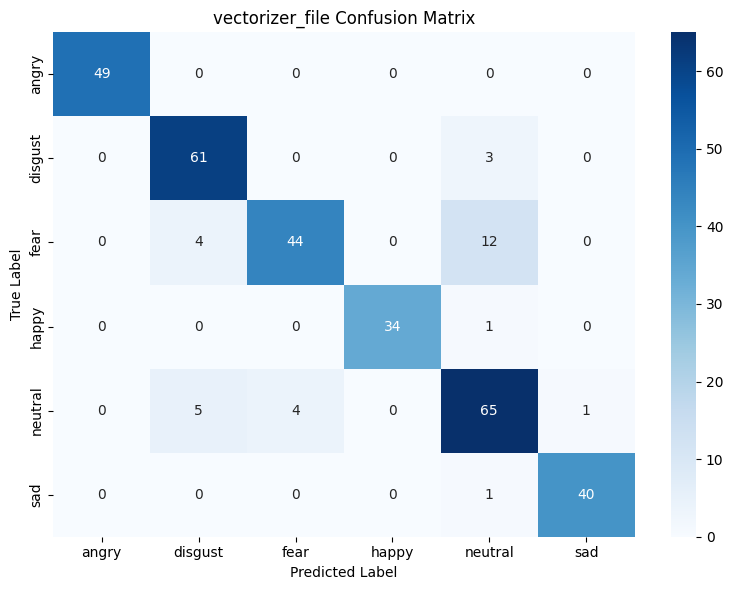

In [15]:
plot_confusion_matrix(
    y_true,
    preds,
    labels,
    title=f"{model_name} Confusion Matrix"
)

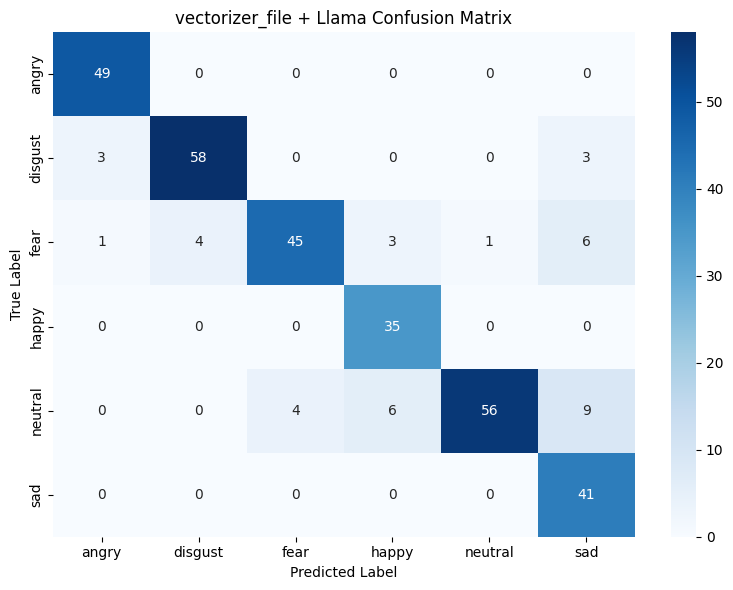

In [16]:
plot_confusion_matrix(
    y_true,
    final_preds,
    labels,
    title=f"{model_name} + Llama Confusion Matrix"
)

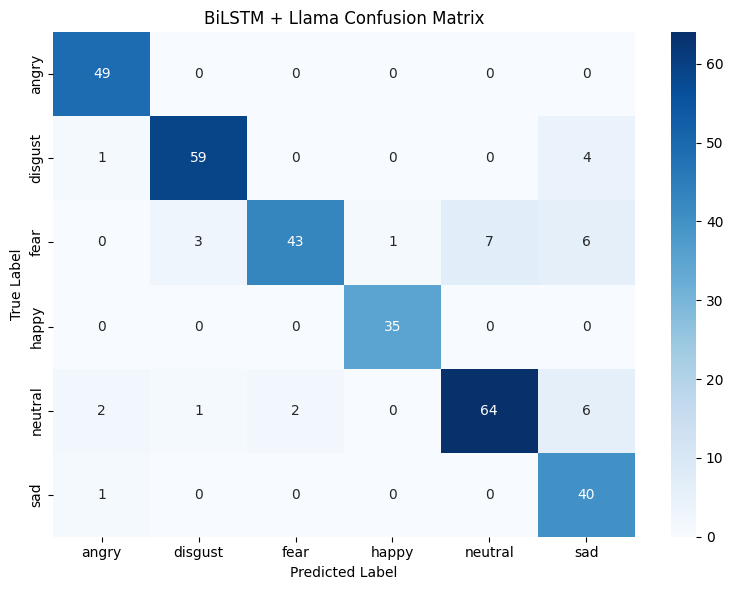

In [18]:
plot_confusion_matrix(
    y_true,
    final_dl_preds,
    labels,
    title="BiLSTM + Llama Confusion Matrix"
)